In [1]:
import os
from IPython.display import Image, display, HTML
import pandas as pd
import matplotlib.pyplot as plt
import boto3
import pickle
from pprint import pprint
import json
import numpy as np
import pandas as pd
import time
from PIL import Image as img
import seaborn as sns

try:
    import catboost
except ModuleNotFoundError:
    ! pip install catboost

## Functions

In [2]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # download file
    boto3.client('s3').download_file(str_project, str_bucket_path, str_local_path)

In [3]:
# show transformers
def show_transformers(list_transformers):
    # iterate
    for a, transformer in enumerate(list_transformers):
        print(f'{a+1}: {transformer.__class__.__name__} - {transformer.str_message}')

## Constants

In [4]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_model = os.getcwd().split('/')[5]
print(f'Model: {str_model}')
str_variant = os.getcwd().split('/')[8][3:]
print(f'Variant: {str_variant}')
str_dirname_output = './output'

Project: 20231010-gen-xii
Model: 02_pricing_pd
Variant: noPTImodel10


## Make output directory

In [5]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

## Data prep

### EDA - part 1

In [6]:
str_filename = 'dict_df_info.json'
str_local_path = f'../../../01_data_prep/02_eda_pt_1/output/{str_filename}'
dict_df_info = json.load(open(str_local_path, 'r'))
df_info = pd.DataFrame(dict_df_info, index=[0])
df_info.columns = ['Rows','Columns','Total Obs.','Min. Date','Max. Date','Target Mean','Prop. NaN']
df_info['Data Set'] = 'All'
df_info = df_info[['Data Set','Rows','Columns','Total Obs.','Min. Date','Max. Date','Prop. NaN','Target Mean']]
df_info

,Data Set,Rows,Columns,Total Obs.,Min. Date,Max. Date,Prop. NaN,Target Mean
0,All,186175,2492,463948100,2013-10-01 07:28:54.833000,2019-12-31 16:55:22.110000,0.223406,0.110101


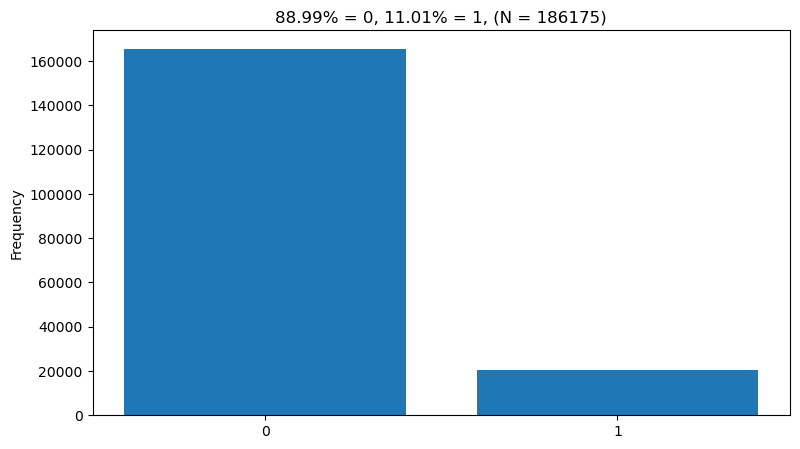

In [7]:
# download
str_filename = 'plt_target.png'
str_local_path = f'../../../01_data_prep/02_eda_pt_1/output/{str_filename}'

# show
Image(filename=str_local_path)

### EDA - part 2

In [8]:
str_filename = 'df_info_summary.csv'
str_local_path = f'../../../01_data_prep/04_eda_pt_2/output/{str_filename}'
df = pd.read_csv(str_local_path)
df

,Data Set,Rows,Columns,Total Obs.,Min. Date,Max. Date,Prop. NaN,Target Mean
0,Train,111705,2492,278368860,2013-10-01 07:28:54.833000,2017-04-15 21:14:58.020000,0.245378,0.116253
1,Valid,37235,2492,92789620,2017-04-16 05:11:45.077000,2018-10-15 13:51:12.850000,0.142046,0.097032
2,Test,37235,2492,92789620,2018-10-15 13:55:55.513000,2019-12-31 16:55:22.110000,0.238850,0.104713


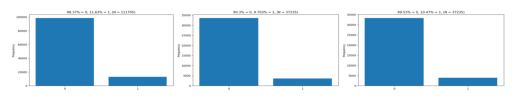

In [9]:
# paths
str_local_path_1 = '../../../01_data_prep/04_eda_pt_2/output/plt_target_train.png'
str_local_path_2 = '../../../01_data_prep/04_eda_pt_2/output/plt_target_valid.png'
str_local_path_3 = '../../../01_data_prep/04_eda_pt_2/output/plt_target_test.png'

# open images
image1 = img.open(str_local_path_1)
image2 = img.open(str_local_path_2)
image3 = img.open(str_local_path_3)

# get the original width
int_width_original = image1.width
# get the height
int_height_original = image1.height
# get the ratio
int_ratio = round(int_width_original / int_height_original)

# set new width
int_width_new = 1000
# calculate new height
int_height_new = round(int_width_new / int_ratio)

# resize
tpl_size = (int_width_new, int_height_new)
image1 = image1.resize(tpl_size)
image2 = image2.resize(tpl_size)
image3 = image3.resize(tpl_size)

# Combine the images side by side
int_width_new_combined = int_width_new * 3
tpl_size = (int_width_new_combined, int_height_new)
combined_image = img.new(
    mode='RGB', 
    size=tpl_size,
)
combined_image.paste(image1, (0, 0))
combined_image.paste(image2, (int_width_new, 0))
combined_image.paste(image3, (int_width_new * 2, 0))

# Display the combined image in the Jupyter Notebook
plt.imshow(combined_image)
plt.axis('off')
plt.show()

### Leaky features

In [10]:
# show leaky features
str_filename = 'df_cols_bad.csv'
str_local_path = f'../../../01_data_prep/05_leaky_features/03_leaky/output/{str_filename}'
df = pd.read_csv(str_local_path)
print(f'There are {df.shape[0]} leaky features:')
# show
df

There are 925 leaky features:


,feature,from_nan,from_df,from_name,sum
0,dtmstampcreation__base,1,1,1,3
1,permid__tu,1,1,1,3
2,acctid__tu,1,1,1,3
3,dtmapproved__tu,1,1,1,3
4,bitsystemdecline__app,1,1,1,3
...,...,...,...,...,...
920,linkb014__tu,1,0,0,1
921,linkb013__tu,1,0,0,1
922,linkb005__tu,1,0,0,1
923,linkb015__tu,1,0,0,1


### EDA - part 3

In [11]:
str_filename = 'df_info_summary.csv'
str_local_path = f'../../../01_data_prep/06_eda_pt_3/output/{str_filename}'
df = pd.read_csv(str_local_path)
df

,Data Set,Rows,Columns,Total Obs.,Min. Date,Max. Date,Prop. NaN,Target Mean
0,Train,111705,1569,175265145,2013-10-01 07:28:54.833000,2017-04-15 21:14:58.020000,0.080201,0.116253
1,Valid,37235,1569,58421715,2017-04-16 05:11:45.077000,2018-10-15 13:51:12.850000,0.079309,0.097032
2,Test,37235,1569,58421715,2018-10-15 13:55:55.513000,2019-12-31 16:55:22.110000,0.080296,0.104713


## Preprocessing

### Step function schematic

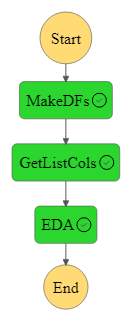

In [12]:
# download
str_filename = 'schematic.png'
str_local_path = f'../../00_preprocessing/05_step_function/img/{str_filename}'

# show
Image(filename=str_local_path)

### Preprocessing model

In [13]:
try:
    str_filename = f'preprocessing.py'
    str_local_path = f'./{str_filename}'
    str_bucket_path = f'01_ad/02_model/{str_variant}/00_preprocessing/01_create_preprocessor/{str_filename}'
    download_from_s3(
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project=str_project,
    )
    str_filename = f'cls_model_preprocessing.pkl'
    str_local_path = f'./{str_filename}'
    str_bucket_path = f'01_ad/02_model/{str_variant}/00_preprocessing/01_create_preprocessor/{str_filename}'
    download_from_s3(
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project=str_project,
    )
    # show pipeline
    list_transformers = pickle.load(open(str_local_path, 'rb')).list_transformers
    print('Preprocessing model steps:')
    show_transformers(list_transformers)

    # rm
    for str_file in [f'preprocessing.py', f'cls_model_preprocessing.pkl']:
        os.remove(str_file)
except:
    pass

Preprocessing model steps:
1: ReplaceNaNs - NaN Replacer
2: SetStrings - Set strings
3: ReplaceBooleans - Boolean Replacer
4: SetDataTypes - Data Type Setter
5: CleanText - Clean text and impute non-numeric
6: Inflator - Inflate to 2022 dollars
7: ClipValues - Clip negative dollar values to zero (automobile and non-automobile)
8: ClipValues - Clip number of income sources to 2
9: CustomImputer - Custom imputer
10: Imputer - Imputer
11: FeatureValueReplacer - Replace zeros with predetermined value
12: DateFeatures - Date features
13: RoundBinning - Round income and amount financed and vehicle values for (LTV)
14: FeatureEngineering - Feature engineering
15: ReplaceInf - Replace inf and -inf with NaN
16: Imputer - Imputer
17: MapTerm - Map term
18: MapPTI - Map PTI
19: RoundBinning - Round values


In [14]:
# get the number of engineered features
str_filename = 'df_list_features.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/01_feat_select/01_lambda_get_starting_feats/{str_filename}'
list_cols = list(pd.read_csv(str_uri)['feature'])
list_cols = [col for col in list_cols if 'ENG-' in col]
print(f'There are {len(list_cols)} engineered features available in the model:')
pprint(list_cols)

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/fsspec/registry.py:275: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


There are 5 engineered features available in the model:
['ENG-applicationdate__app_month',
 'ENG-applicationdate__app_quarter',
 'ENG-loan_to_value',
 'ENG-vehicle_age',
 'ENG-dealership_age']


In [15]:
str_filename = 'df_info_summary.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/00_preprocessing/04_eda/{str_filename}'
df = pd.read_csv(str_uri)
df

,Data Set,Rows,Columns,Total Obs.,Min. Date,Max. Date,Prop. NaN,Target Mean
0,Train,111705,1577,176158785,2013-10-01 07:28:54.833000,2017-04-15 21:14:58.020000,0.001003,0.116253
1,Valid,37235,1577,58719595,2017-04-16 05:11:45.077000,2018-10-15 13:51:12.850000,0.001068,0.097032
2,Test,37235,1577,58719595,2018-10-15 13:55:55.513000,2019-12-31 16:55:22.110000,0.001157,0.104713


## Feature selection

### Step function schematic

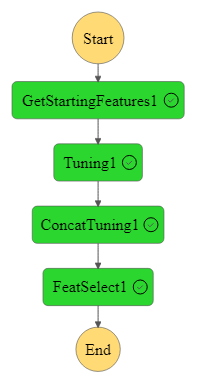

In [16]:
# download
str_filename = 'schematic.png'
str_local_path = f'../../01_feat_select/05_step_function/img/{str_filename}'

# show
Image(filename=str_local_path)

### Hyperparameters for step function

In [17]:
str_filename = 'df_hyperparameters.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/01_feat_select/05_step_function/{str_filename}'
df = pd.read_csv(str_uri)
# show
df

,keys,values
0,STR_FILENAME_TRAIN,df_train_noleaks_pre.gzip
1,STR_FILENAME_VALID,df_valid_noleaks_pre.gzip
2,INT_N_ITERATIONS,1000
3,PROP_EARLY_STOPPING,0.05
4,INT_N_TUNING_JOBS_1,100
5,STR_EVAL_METRIC,Logloss


### Starting features

In [18]:
str_filename = 'df_list_features.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/01_feat_select/01_lambda_get_starting_feats/{str_filename}'
df = pd.read_csv(str_uri)
print(f'There were {df.shape[0]} features eligible for the model')

There were 1444 features eligible for the model


### Tuning

In [19]:
str_filename = 'df_tuning.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/01_feat_select/03_lambda_concat_tuning/{str_filename}'
df = pd.read_csv(str_uri)
# show
df

,iteration,learning_rate,flt_eval_metric_train,flt_eval_metric_valid,diff,best_iteration
0,6,0.0615,0.340906,0.353797,0.012891,547
1,14,0.1421,0.347492,0.354010,0.006518,232
2,9,0.0917,0.338148,0.354895,0.016746,375
3,8,0.0816,0.348830,0.355803,0.006973,336
4,10,0.1018,0.345794,0.356190,0.010396,276
...,...,...,...,...,...,...
95,88,0.8881,0.406355,0.376303,0.030052,7
96,81,0.8175,0.403473,0.377594,0.025879,10
97,87,0.8780,0.409212,0.379815,0.029397,5
98,89,0.8982,0.410782,0.383627,0.027155,4


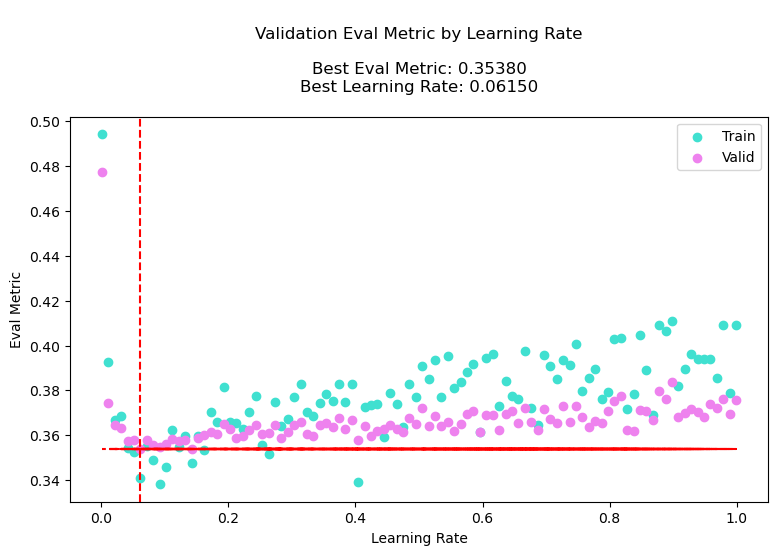

In [20]:
# plot
fig, ax = plt.subplots(figsize=(9,5))
flt_best_lr = df['learning_rate'].iloc[0]
flt_best_metric = df['flt_eval_metric_valid'].iloc[0]
str_title = f"""
Validation Eval Metric by Learning Rate

Best Eval Metric: {flt_best_metric:0.5f}
Best Learning Rate: {flt_best_lr:0.5f}
"""
ax.set_title(str_title)
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Eval Metric')
ax.scatter(df['learning_rate'], df['flt_eval_metric_train'], label='Train', color='turquoise')
ax.scatter(df['learning_rate'], df['flt_eval_metric_valid'], label='Valid', color='violet')
ax.axvline(x=flt_best_lr, linestyle='--', color='red')
ax.plot(df['learning_rate'], [flt_best_metric for a in range(df.shape[0])], linestyle='--', color='red')
plt.legend()
# save and show
plt.savefig(f'{str_dirname_output}/plt_tuning_1.png', bbox_inches='tight')
plt.show()

In [21]:
# get the model with the best validation metric to visualize overfitting
bool_ascending = False
df_tmp = df.sort_values(by='flt_eval_metric_valid', ascending=bool_ascending, inplace=False)
flt_eval_metric_train_0 = df_tmp['flt_eval_metric_train'].iloc[0]
flt_eval_metric_valid_0 = df_tmp['flt_eval_metric_valid'].iloc[0]
print(f'Best Validation Job 1: Train score: {flt_eval_metric_train_0:0.5f}; Valid score: {flt_eval_metric_valid_0:0.5f}')

Best Validation Job 1: Train score: 0.49422; Valid score: 0.47726


In [22]:
# get the metrics we want to match up with
flt_eval_metric_train_1 = df['flt_eval_metric_train'].iloc[0]
flt_eval_metric_valid_1 = df['flt_eval_metric_valid'].iloc[0]
print(f'Best Tuning Job 1: Train score: {flt_eval_metric_train_1:0.5f}; Valid score: {flt_eval_metric_valid_1:0.5f}')

Best Tuning Job 1: Train score: 0.34091; Valid score: 0.35380


### Feature selection

In [23]:
# get output from feature selection
str_filename = 'df_iterative_feat_select.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/01_feat_select/04_batch_feature_selection/results/{str_filename}'
df = pd.read_csv(str_uri)
df

,iteration,learning_rate,flt_eval_metric_train,flt_eval_metric_valid,diff,n_feats,list_cols_model,best_iteration
0,0,0.0615,0.340906,0.353797,0.012891,1442,"['linkf060__tu', 'linkf045__tu', 'linkf185__tu...",547
1,1,0.0615,0.360828,0.363037,0.002209,360,"['fltgrossmonthly__income_sum', 'intopenbktype...",330
2,2,0.0615,0.383011,0.371620,0.011392,197,"['fltgrossmonthly__income_sum', 'intopenbktype...",257
3,3,0.0615,0.375797,0.363758,0.012038,146,"['fltgrossmonthly__income_sum', 'intopenbktype...",316
4,4,0.0615,0.371486,0.360578,0.010909,126,"['fltgrossmonthly__income_sum', 'intopenbktype...",394
5,5,0.0615,0.368413,0.361988,0.006426,105,"['fltgrossmonthly__income_sum', 'bankruptcysta...",425
6,6,0.0615,0.375522,0.364189,0.011333,92,"['fltgrossmonthly__income_sum', 'intopenbktype...",325
7,7,0.0615,0.367742,0.362805,0.004937,87,"['fltgrossmonthly__income_sum', 'intopenbktype...",467
8,8,0.0615,0.377404,0.364573,0.012831,79,"['fltgrossmonthly__income_sum', 'intopenbktype...",321
9,9,0.0615,0.377386,0.364298,0.013088,76,"['fltgrossmonthly__income_sum', 'intopenbktype...",338


In [24]:
# get cols in model
str_filename = 'df_cols_in_model.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/01_lambda_get_starting_feats/{str_filename}'
list_cols = list(pd.read_csv(str_uri)['feature'])

# get cols that were dropped
str_filename = 'df_feats_to_drop.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/01_lambda_get_starting_feats/{str_filename}'
list_feats_drop = list(pd.read_csv(str_uri)['feature'])

# merge lists
list_cols = list_cols + list_feats_drop
list_cols = list(dict.fromkeys(list_cols)) # rm dups

# get n cols
int_n_cols = len(list_cols)
print(f'There were {int_n_cols} features selected from feature selection:')
#pprint(list_cols)

# get best iteration
#int_best_iteration = df[df['n_feats']==int_n_cols]['iteration'].iloc[0]

There were 124 features selected from feature selection:


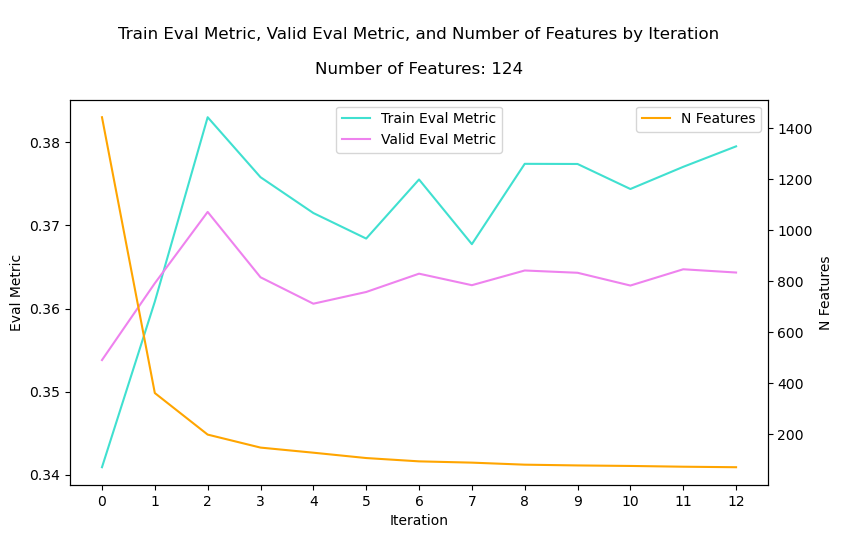

In [25]:
# plot
df.sort_values(by='iteration', ascending=True, inplace=True)
fig, ax = plt.subplots(figsize=(9,5))
# str_title = f"""
# Train Eval Metric, Valid Eval Metric, and Number of Features by Iteration\n
# Best Iteration: {int_best_iteration}; Number of Features: {int_n_cols}
# """
str_title = f"""
Train Eval Metric, Valid Eval Metric, and Number of Features by Iteration\n
Number of Features: {int_n_cols}
"""
ax.set_title(str_title)
ax.set_xlabel('Iteration')
ax.set_ylabel('Eval Metric')
ax.plot(df['iteration'].astype(str), df['flt_eval_metric_train'], label='Train Eval Metric', color='turquoise')
ax.plot(df['iteration'].astype(str), df['flt_eval_metric_valid'], label='Valid Eval Metric', color='violet')
#ax.axvline(int_best_iteration, label='Best Iteration', color='red', linestyle='--')
plt.legend(loc='upper center')

ax2 = ax.twinx()
ax2.set_ylabel('N Features')
ax2.plot(df['iteration'].astype(str), df['n_feats'], color='orange', label='N Features')
plt.legend(loc='upper right')
plt.savefig(f'{str_dirname_output}/plt_feat_select_1.png', bbox_inches='tight')
plt.show()

In [26]:
# get the metrics we want to match up with
flt_eval_metric_train_2 = df['flt_eval_metric_train'].iloc[0]
flt_eval_metric_valid_2 = df['flt_eval_metric_valid'].iloc[0]
print(f'First Iteration of Feature Selection: Train score: {flt_eval_metric_train_2:0.5f}; Valid score: {flt_eval_metric_valid_2:0.5f}')

First Iteration of Feature Selection: Train score: 0.34091; Valid score: 0.35380


In [27]:
# make sure the first iteration of feature selection matches with best tuning job
if (flt_eval_metric_train_1 == flt_eval_metric_train_2) and (flt_eval_metric_valid_1 == flt_eval_metric_valid_2):
    print('Success, the first iteration of feature selection matches the best tuning job.')
else:
    print('Alert! The first iteration of feature selection does not match the best tuning job')

Success, the first iteration of feature selection matches the best tuning job.


In [28]:
# save more metrics for matching
# flt_eval_metric_train_3 = df[df['n_feats']==int_n_cols]['flt_eval_metric_train'].iloc[0]
# flt_eval_metric_valid_3 = df[df['n_feats']==int_n_cols]['flt_eval_metric_valid'].iloc[0]
# print(f'Best List of Features from Feature Selection: Train score: {flt_eval_metric_train_3:0.5f}; Valid score: {flt_eval_metric_valid_3:0.5f}')

## Model building

### Step function schematic

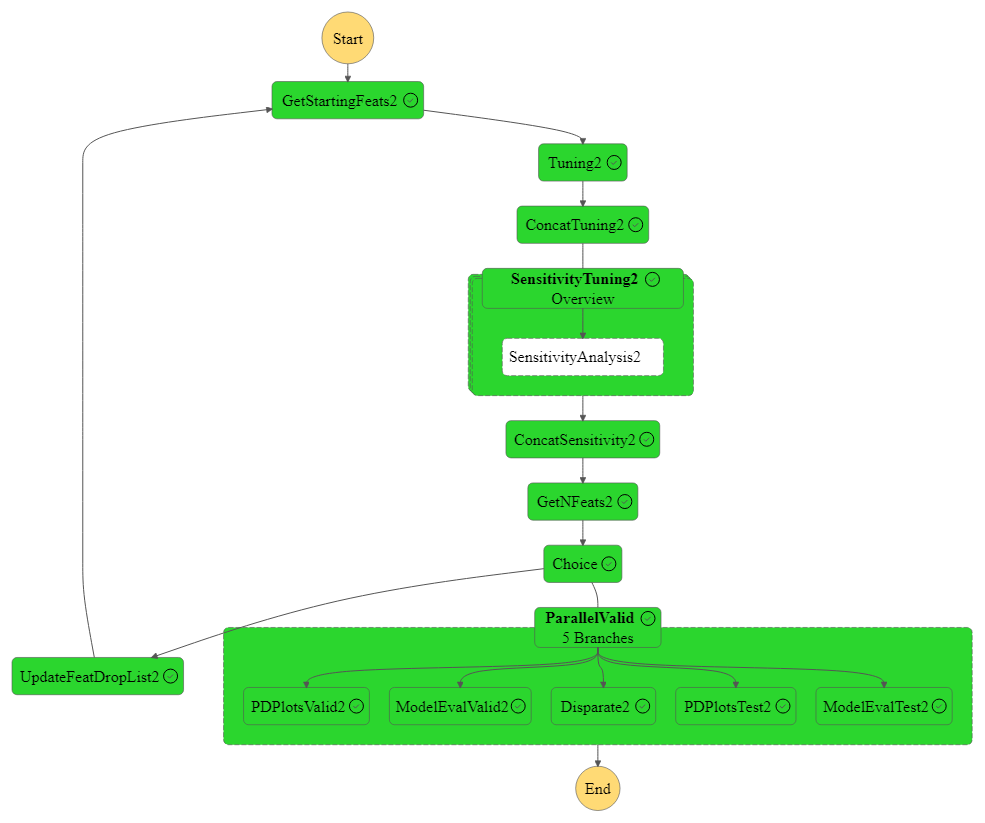

In [29]:
# download
str_filename = 'schematic.png'
str_local_path = f'../../02_model/12_step_function/img/{str_filename}'

# show
Image(filename=str_local_path)

### Hyperparameters for step function

In [30]:
str_filename = 'df_hyperparameters.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/12_step_function/{str_filename}'
df = pd.read_csv(str_uri)
# show
df

,keys,values
0,STR_FILENAME_TRAIN,df_train_noleaks_pre.gzip
1,STR_FILENAME_VALID,df_valid_noleaks_pre.gzip
2,STR_FILENAME_TEST,df_test_noleaks_pre.gzip
3,INT_N_ITERATIONS,1000
4,PROP_EARLY_STOPPING,0.05
5,INT_N_TUNING_JOBS_2,50
6,STR_EVAL_METRIC,Logloss


### Features to drop

In [31]:
str_filename = 'df_feats_to_drop.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/01_lambda_get_starting_feats/{str_filename}'
list_feats_drop = list(pd.read_csv(str_uri)['feature'])
print(f'There is/are {len(list_feats_drop)} feature(s) to drop:')
pprint(list_feats_drop)

There is/are 2 feature(s) to drop:
['rev255__tu', 'confirmationinputaddress__ln']


/tmp/ipykernel_10764/686182515.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(df['feature']), rotation=90)


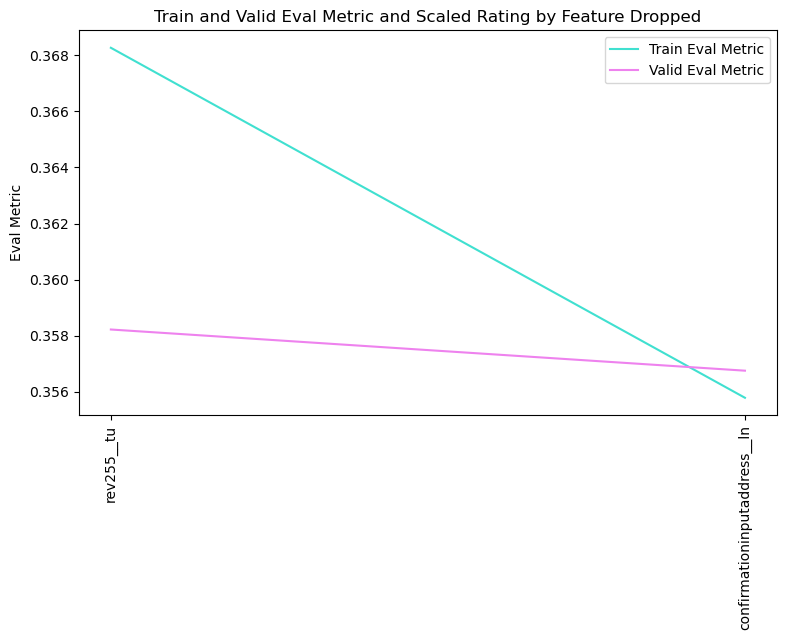

In [32]:
try:
    list_df = []
    for col in list_feats_drop:
        # import
        str_filename = f'df_output_{col}.csv'
        str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/04_batch_sensitivity_analysis/models/{str_filename}'
        df = pd.read_csv(str_uri)
        # append
        list_df.append(df)
    # create df
    df = pd.concat(list_df)

    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title('Train and Valid Eval Metric and Scaled Rating by Feature Dropped')
    ax.set_ylabel('Eval Metric')
    ax.plot(df['feature'], df['flt_eval_metric_train'], color='turquoise', label='Train Eval Metric')
    ax.plot(df['feature'], df['flt_eval_metric_valid'], color='violet', label='Valid Eval Metric')
    ax.set_xticklabels(list(df['feature']), rotation=90)
    plt.legend()
    # save
    plt.savefig(f'{str_dirname_output}/plt_dropped_features.png', bbox_inches='tight')
    plt.show()
except ValueError:
    pass

### Features in the model

In [33]:
str_filename = 'df_cols_in_model.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/01_lambda_get_starting_feats/{str_filename}'
list_cols_model = list(pd.read_csv(str_uri)['feature'])
print(f'There are {len(list_cols_model)} features in the model:')
if len(list_cols_model) <= 100:
    pprint(list_cols_model)
else:
    pass

There are 122 features in the model:


### Tuning

In [34]:
str_filename = 'df_tuning.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/03_lambda_concat_tuning/{str_filename}'
df = pd.read_csv(str_uri)
# show
df.head(10)

,iteration,learning_rate,flt_eval_metric_train,flt_eval_metric_valid,diff,best_iteration
0,25,0.2530,0.355787,0.356753,0.000966,169
1,9,0.0917,0.356760,0.356925,0.000164,438
2,20,0.2026,0.363245,0.357323,0.005922,173
3,12,0.1220,0.364997,0.358606,0.006391,267
4,17,0.1724,0.364984,0.358800,0.006184,186
5,14,0.1421,0.362902,0.359284,0.003619,252
6,13,0.1321,0.367206,0.359500,0.007706,239
7,26,0.2631,0.365882,0.360630,0.005252,128
8,4,0.0413,0.366621,0.360845,0.005776,839
9,19,0.1925,0.375980,0.360994,0.014986,125


In [35]:
df.tail(10)

,iteration,learning_rate,flt_eval_metric_train,flt_eval_metric_valid,diff,best_iteration
40,28,0.2833,0.393159,0.368817,0.024341,52
41,35,0.3538,0.388096,0.369175,0.018920,50
42,2,0.0212,0.386075,0.369518,0.016557,935
43,38,0.3841,0.398340,0.369537,0.028802,29
44,44,0.4446,0.390008,0.369776,0.020231,38
45,29,0.2933,0.395034,0.370262,0.024773,45
46,48,0.4849,0.396390,0.371130,0.025260,26
47,45,0.4546,0.393339,0.371467,0.021872,32
48,1,0.0111,0.404289,0.378956,0.025333,999
49,0,0.0010,0.495437,0.477356,0.018081,999


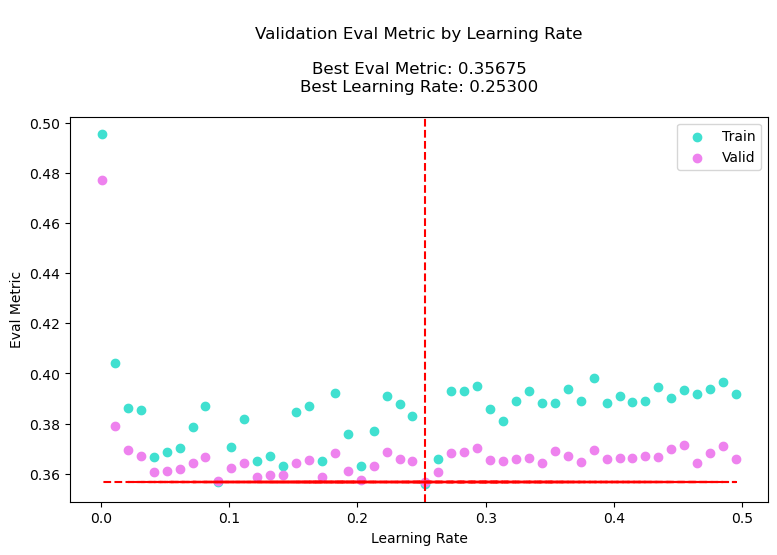

In [36]:
# plot
fig, ax = plt.subplots(figsize=(9,5))
flt_best_lr = df['learning_rate'].iloc[0]
flt_best_metric = df['flt_eval_metric_valid'].iloc[0]
str_title = f"""
Validation Eval Metric by Learning Rate

Best Eval Metric: {flt_best_metric:0.5f}
Best Learning Rate: {flt_best_lr:0.5f}
"""
ax.set_title(str_title)
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Eval Metric')
ax.scatter(df['learning_rate'], df['flt_eval_metric_train'], label='Train', color='turquoise')
ax.scatter(df['learning_rate'], df['flt_eval_metric_valid'], label='Valid', color='violet')
ax.axvline(x=flt_best_lr, linestyle='--', color='red')
ax.plot(df['learning_rate'], [flt_best_metric for a in range(df.shape[0])], linestyle='--', color='red')
plt.legend()
# save and show
plt.savefig(f'{str_dirname_output}/plt_tuning_2.png', bbox_inches='tight')
plt.show()

In [37]:
# get the metrics we want to match up with
flt_eval_metric_train_4 = df['flt_eval_metric_train'].iloc[0]
flt_eval_metric_valid_4 = df['flt_eval_metric_valid'].iloc[0]
print(f'Best Tuning Job 2: Train score: {flt_eval_metric_train_4:0.5f}; Valid score: {flt_eval_metric_valid_4:0.5f}')

Best Tuning Job 2: Train score: 0.35579; Valid score: 0.35675


In [38]:
# # make sure the best tuning job 2 has a valid eval metric >= the best validation metric from feature selection
# if flt_eval_metric_valid_4 >= flt_eval_metric_valid_3:
#     print('Success, the best tuning job has validation performance at least as good as the best feature selection job.')
# else:
#     print('Alert! The best tuning job has validation performance worse than the best feature selection job.')

### Progress table

In [39]:
# df = pd.DataFrame({
#     'Step': ['Tuning 1 - Best Valid', 'Tuning 1 - Best', 'Feature Selection - First', 'Feature Selection - Best', 'Tuning 2 - Best'],
#     'Train': [flt_eval_metric_train_0, flt_eval_metric_train_1, flt_eval_metric_train_2, flt_eval_metric_train_3, flt_eval_metric_train_4],
#     'Valid': [flt_eval_metric_valid_0, flt_eval_metric_valid_1, flt_eval_metric_valid_2, flt_eval_metric_valid_3, flt_eval_metric_valid_4],
# })
# # show
# df

In [40]:
# # make grouped bar plot
# df_long = pd.melt(
#     df,
#     id_vars=['Step'],
#     var_name='Data Set',
#     value_name='Score',
# )
# # get ymin and max
# flt_ymax = np.max(df_long['Score'])
# flt_ymin = np.min(df_long['Score'])
# flt_range = flt_ymax - flt_ymin
# flt_ymin = flt_ymin - flt_range
# flt_ymax = flt_ymax + flt_range

# # plot
# fig, ax = plt.subplots(figsize=(9,5))
# ax.set_title('Train and Valid Score by Step')
# sns.barplot(data=df_long, x='Step', y='Score', hue='Data Set', ax=ax, palette=['turquoise','violet'])
# # horizontal line - train
# ax.axhline(df['Train'].iloc[-1], linestyle='--', color='red')
# # horizontal line - valid
# ax.axhline(df['Valid'].iloc[-1], linestyle='--', color='red')
# ax.set_xticklabels(list(df['Step']), rotation=45)
# ax.set_ylim(bottom=flt_ymin, top=flt_ymax)
# plt.legend(loc='upper right')
# # save and show
# str_filename = 'plt_progress_table.png'
# str_local_path =  f'{str_dirname_output}/{str_filename}'
# plt.savefig(str_local_path, bbox_inches='tight')
# plt.show()

### Hyperparameters

In [41]:
# download model
str_filename = 'final_model.pkl'
str_local_path = f'./{str_filename}'
str_bucket_path = f'{str_model}/02_model/{str_variant}/03_final_model/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
# show pipeline
cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
print('')
print('Hyperparameters:')
pprint(cls_model_inference.get_params())

# rm
os.remove(str_local_path)


Hyperparameters:
{'class_weights': [0.7891395476048177, 2.6029518712459567],
 'eval_metric': 'Logloss',
 'iterations': 1000,
 'learning_rate': 0.253,
 'monotone_constraints': {'ENG-loan_to_value': 1,
                          'ENG-vehicle_age': 1,
                          'fltadvance__app': 1,
                          'fltapproveddowntotal__app': -1,
                          'fltdowncash__app': -1,
                          'fltgrossmonthly__income_sum': -1},
 'nan_mode': 'Min',
 'random_state': 42,
 'task_type': 'CPU'}


### Sensitivity analysis

In [42]:
# feat importance (via sensitivity analysis)
list_cols = [
    'feature',
    'flt_eval_metric_train',
    'flt_eval_metric_valid',
    'flt_score_to_beat',
    'performance',
    'helped',
]
str_filename = 'df_sensitivity.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/05_lambda_concat_sensitivity/{str_filename}'
df = pd.read_csv(str_uri, usecols=list_cols)
df.sort_values(by='performance', ascending=True, inplace=True)

# get description
list_cols = [
    'feature',
    'description',
]
str_filename_tmp = 'df_descriptions.csv'
str_local_path = f'../../../../ad_hoc/06_get_descriptions_all/output/{str_variant}/{str_filename_tmp}'
df_descriptions = pd.read_csv(str_local_path, usecols=list_cols)

# join
df = pd.merge(
    left=df,
    right=df_descriptions,
    on='feature',
    how='left',
)

# save
str_local_path = f'{str_dirname_output}/{str_filename}'
df.to_csv(str_local_path, index=False)

int_n_feats = 10
print(f'{int_n_feats} most important features:')
df.head(int_n_feats)

10 most important features:


,feature,flt_eval_metric_train,flt_eval_metric_valid,flt_score_to_beat,performance,helped,description
0,bankruptcystatus__ln,0.387762,0.378202,0.356753,-0.021449,0,Indicates status of most recent bankruptcy fil...
1,re01s__tu,0.397615,0.372752,0.356753,-0.015999,0,Number of revolving trades
2,at28b__tu,0.399784,0.372407,0.356753,-0.015654,0,Total credit line of open trades verified in p...
3,bitgap__app,0.393054,0.371837,0.356753,-0.015084,0,Gap tag
4,addrlastmovetaxratiodiff__ln,0.398388,0.371752,0.356753,-0.014999,0,Ratio comparing the difference in tax assessed...
5,fltgrossmonthly__income_sum,0.374545,0.371340,0.356753,-0.014587,0,Total income
6,at35a__tu,0.392956,0.371162,0.356753,-0.014409,0,Average balance of open trades verified in pas...
7,at25s__tu,0.397033,0.371155,0.356753,-0.014403,0,Number of currently open and satisfactory trad...
8,rev315__tu,0.395684,0.371008,0.356753,-0.014255,0,Number of months since Max Total Open-to-Buy f...
9,addrinputtimenewest__ln,0.395141,0.370964,0.356753,-0.014211,0,Time on file (in months) since the subject was...


In [43]:
# least important features
df.sort_values(by='performance', ascending=False, inplace=True)
print(f'{int_n_feats} least important features:')
df.head(int_n_feats)

10 least important features:


,feature,flt_eval_metric_train,flt_eval_metric_valid,flt_score_to_beat,performance,helped,description
121,s207a__tu,0.356338,0.358108,0.356753,-0.001355,0,Months since most recent tradeline bankruptcy
120,of21s__tu,0.363463,0.358771,0.356753,-0.002019,0,Months since most recent credit union trade op...
119,fi24s__tu,0.369822,0.359256,0.356753,-0.002503,0,Number of currently open and satisfactory fina...
118,fltapproveddowntotal__app,0.367848,0.359904,0.356753,-0.003151,0,Total down
117,at103s__tu,0.360886,0.360629,0.356753,-0.003876,0,Percentage of satisfactory open trades to all ...
116,sourcenonderogcount__ln,0.364770,0.360641,0.356753,-0.003888,0,Total non-derogatory source types on file for ...
115,walshr10__tu,0.372690,0.360989,0.356753,-0.004236,0,Months since most recent wallet share shift > ...
114,rvdexq3__tu,0.371597,0.361086,0.356753,-0.004333,0,Q3 (Jul - Sep) revolving spend indexed to revo...
113,linkt002__tu,0.381547,0.361526,0.356753,-0.004773,0,Number of months at current address
112,bc20s__tu,0.370611,0.361576,0.356753,-0.004823,0,Months since oldest credit card trade opened


In [44]:
# get number of features that helped the model once they were removed
int_sum_helped = np.sum(df['helped'])
print(f'There were/was {int_sum_helped} feature(s) that helped model performance...')
if int_sum_helped > 0:
    print('Consider removing feature(s) that helped model and re-evaluate')
else:
    print('All features compromised model performance upon removal.')

There were/was 0 feature(s) that helped model performance...
All features compromised model performance upon removal.


/tmp/ipykernel_10764/3261082257.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_tmp['feature'], rotation=90)


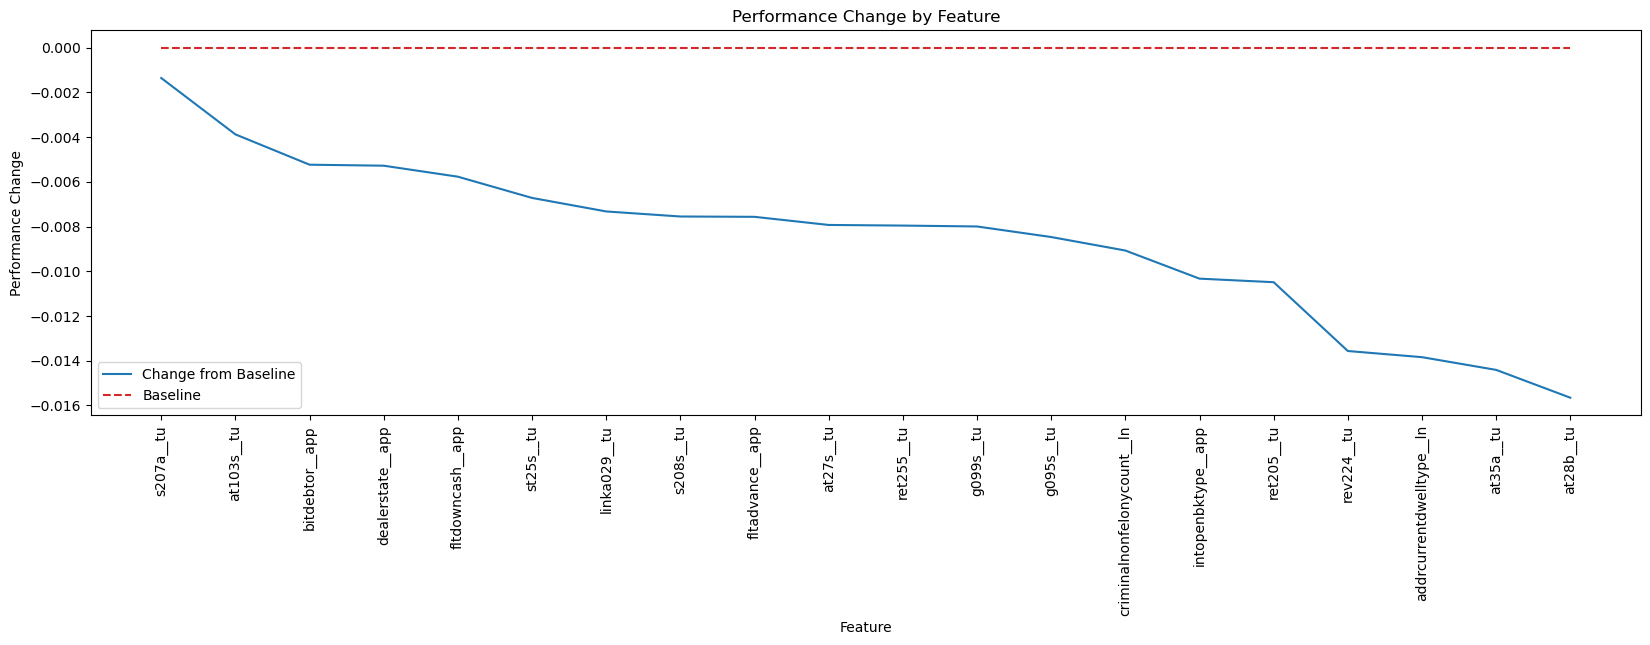

In [45]:
# take random sample to make plotting clearer
try:
    df_tmp = df.sample(n=20, random_state=42)
except ValueError:
    df_tmp = df.sample(n=df.shape[0], random_state=42)
df_tmp.sort_values(by='performance', ascending=False, inplace=True)

# plot
fig, ax = plt.subplots(figsize=(df_tmp.shape[0], 5))
ax.set_title('Performance Change by Feature')
ax.set_xlabel('Feature')
ax.set_ylabel('Performance Change')
ax.plot(df_tmp['feature'], df_tmp['performance'], label='Change from Baseline')
ax.plot(df_tmp['feature'], [0]*df_tmp.shape[0], linestyle='--', color='tab:red', label='Baseline')
ax.set_xticklabels(df_tmp['feature'], rotation=90)
plt.legend()
plt.savefig(f'{str_dirname_output}/plt_sensitivity_2.png', bbox_inches='tight')
plt.show()

### Disparate Impact - Valid

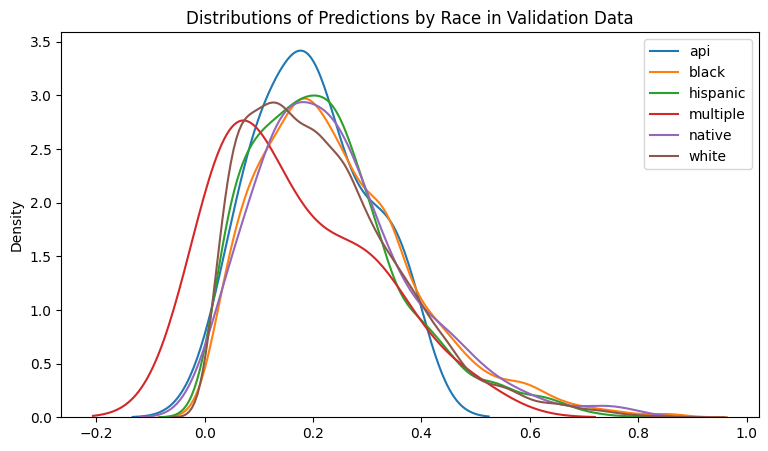

In [46]:
# race
str_filename = 'plt_yhat_dist_race.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=f'{str_model}/02_model/{str_variant}/02_model/11b_disparate_impact/{str_filename}', 
    str_project=str_project,
)
# show
Image(filename=str_local_path)

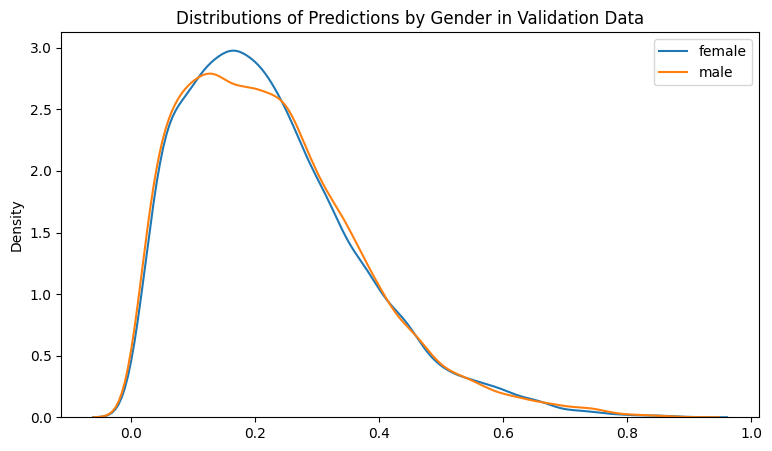

In [47]:
# gender
str_filename = 'plt_yhat_dist_gender.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=f'{str_model}/02_model/{str_variant}/02_model/11b_disparate_impact/{str_filename}', 
    str_project=str_project,
)
# show
Image(filename=str_local_path)

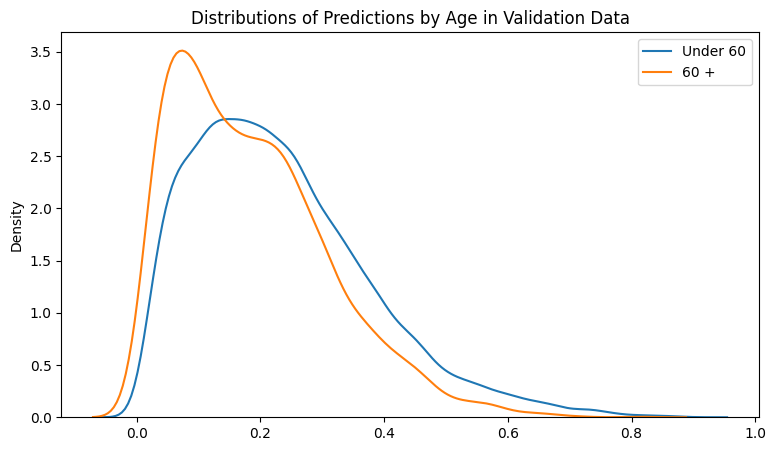

In [48]:
# age
str_filename = 'plt_yhat_dist_age.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=f'{str_model}/02_model/{str_variant}/02_model/11b_disparate_impact/{str_filename}',
    str_project=str_project,
)
# show
Image(filename=str_local_path)

In [49]:
# top features
list_str_filename = [
    'df_feat_imp_race.csv',
    'df_feat_imp_gender.csv',
    'df_feat_imp_age.csv',
]
list_list_features = []
for str_filename in list_str_filename:
    str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/11b_disparate_impact/{str_filename}'
    list_features = list(pd.read_csv(str_uri)['feature'])[:10]
    list_list_features.append(list_features)
# flatten list
list_features = [item for sublist in list_list_features for item in sublist]
# rm dups
list_features = list(dict.fromkeys(list_features))

# tag
df['disparate_feature'] = df['feature'].apply(lambda x: 1 if x in list_features else 0)
# subset
df = df[df['disparate_feature'] == 1]
# sort
df.sort_values(by='performance', ascending=True, inplace=True)

# save
str_filename = 'df_disparate.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df.to_csv(str_uri, index=False)

# show
df

,feature,flt_eval_metric_train,flt_eval_metric_valid,flt_score_to_beat,performance,helped,description,disparate_feature
1,re01s__tu,0.397615,0.372752,0.356753,-0.015999,0,Number of revolving trades,1
2,at28b__tu,0.399784,0.372407,0.356753,-0.015654,0,Total credit line of open trades verified in p...,1
4,addrlastmovetaxratiodiff__ln,0.398388,0.371752,0.356753,-0.014999,0,Ratio comparing the difference in tax assessed...,1
5,fltgrossmonthly__income_sum,0.374545,0.371340,0.356753,-0.014587,0,Total income,1
11,addrinputavmvalue12month__ln,0.394847,0.370746,0.356753,-0.013993,0,Indicates input address AVM value on file 12 m...,1
26,g106s__tu,0.392490,0.367996,0.356753,-0.011243,0,Months on file,1
27,derogseverityindex__ln,0.386951,0.367364,0.356753,-0.010611,0,Index indicating severity of derogatory record...,1
29,addrpreviouslengthofres__ln,0.389682,0.367297,0.356753,-0.010545,0,Length of residency in previous residence,1
36,jt01s__tu,0.384457,0.366705,0.356753,-0.009952,0,Number of joint trades,1
69,linkt007__tu,0.386460,0.364673,0.356753,-0.007921,0,Months since most recent derogatory public record,1


/tmp/ipykernel_10764/308851004.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['feature'], rotation=90)


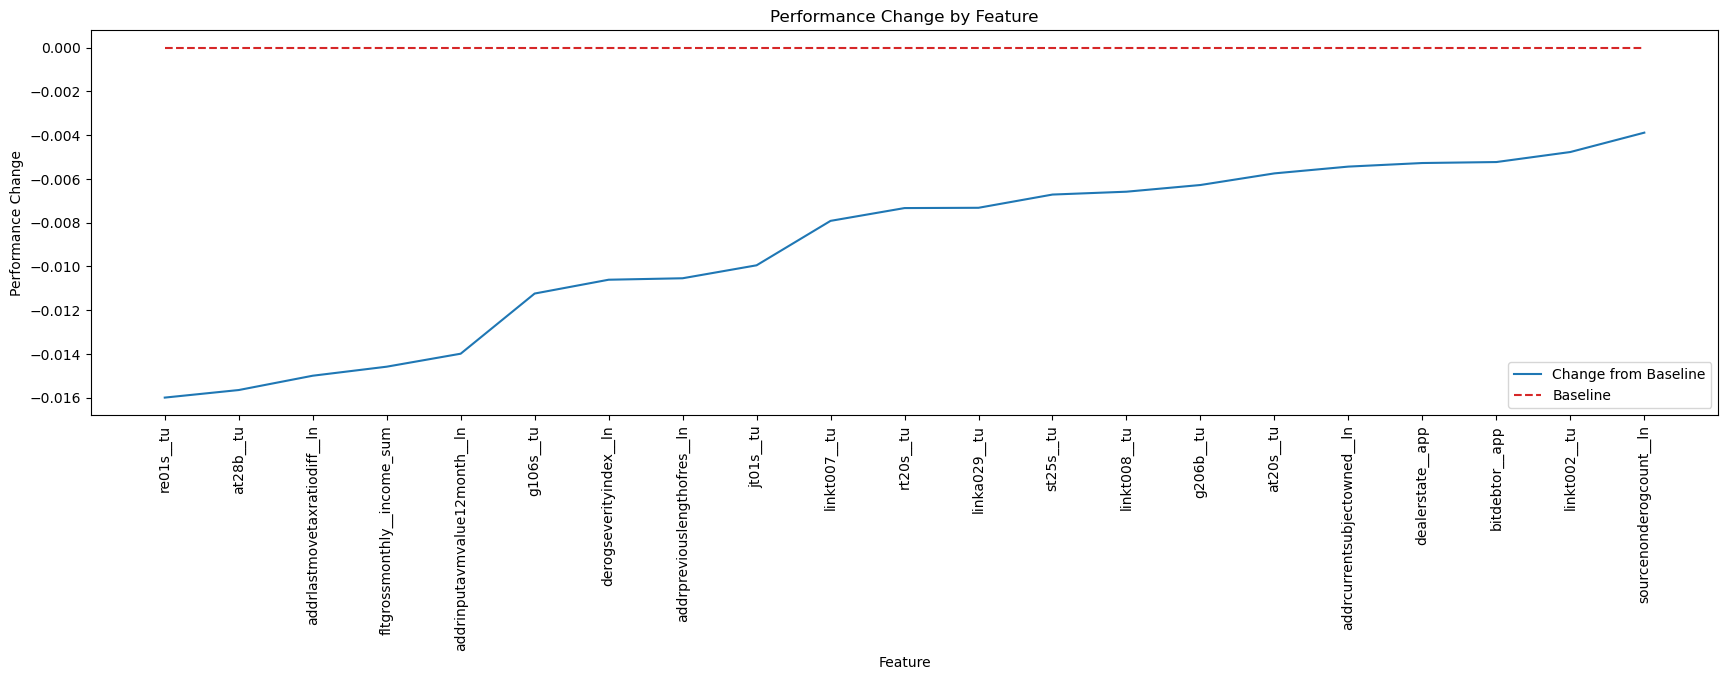

In [50]:
# plot
fig, ax = plt.subplots(figsize=(df.shape[0], 5))
ax.set_title('Performance Change by Feature')
ax.set_xlabel('Feature')
ax.set_ylabel('Performance Change')
ax.plot(df['feature'], df['performance'], label='Change from Baseline')
ax.plot(df['feature'], [0]*df.shape[0], linestyle='--', color='tab:red', label='Baseline')
ax.set_xticklabels(df['feature'], rotation=90)
plt.legend()
plt.savefig(f'{str_dirname_output}/plt_disparate.png', bbox_inches='tight')
plt.show()

### PD Plots - Valid

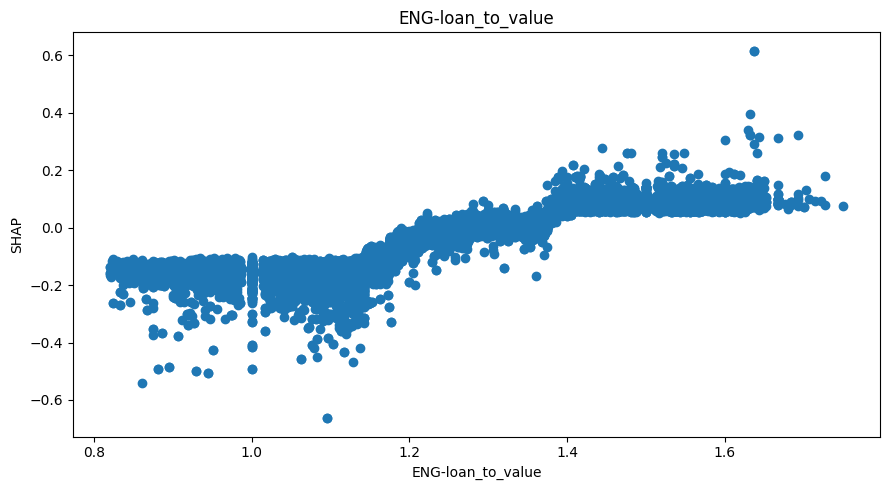

In [51]:
# get the most recently uploaded file
str_prefix = f'{str_model}/02_model/{str_variant}/02_model/08_batch_pd_plots_valid/plots'
cls_s3 = boto3.resource('s3')
# initialize bucket
cls_bucket = cls_s3.Bucket(str_project)
# use the bucket objects method to get a list of all objects in the bucket with the specified prefix
objects = cls_bucket.objects.filter(Prefix=str_prefix)
# sort the objects by last modified time
list_sorted_objects = sorted(objects, key=lambda x: x.last_modified, reverse=False)
# get the keys
list_sorted_objects = [obj.key for obj in list_sorted_objects]
# make sure gzip
list_sorted_objects = [str_key for str_key in list_sorted_objects if '.png' in str_key]
# get the key (i.e. filename) of the most recently modified object
str_filename = list_sorted_objects[0].split('/')[-1]

# download
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_prefix}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)

# show
Image(filename=str_local_path)

### Model eval - Valid

In [52]:
# download
str_filename = 'dict_eval_metrics_train.json'
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_model}/02_model/{str_variant}/02_model/09_batch_model_eval_valid/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
# open
with open(str_local_path, 'r') as f:
    # Load the contents of the file as a Python object
    dict_metrics_train = json.load(f)

# make df
ser_metrics_train = pd.Series(dict_metrics_train)
df_metrics_train = pd.DataFrame({'train': ser_metrics_train})

# download
str_filename = 'dict_eval_metrics_valid.json'
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_model}/02_model/{str_variant}/02_model/09_batch_model_eval_valid/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
# open
with open(str_local_path, 'r') as f:
    # Load the contents of the file as a Python object
    dict_metrics_valid = json.load(f)

# make df
ser_metrics_valid = pd.Series(dict_metrics_valid)
df_metrics_valid = pd.DataFrame({'valid': ser_metrics_valid})

# join
df_metrics = df_metrics_train.join(df_metrics_valid)

# save
str_filename = 'df_valid_model_eval_metrics.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_metrics.to_csv(str_local_path, index=False)

# show
df_metrics

,train,valid
accuracy,0.305895,0.272271
precision,0.142550,0.114131
recall,0.991144,0.961251
f1,0.249252,0.204036
roc_auc,0.843368,0.726387
pr_auc,0.466393,0.240346
log_loss,0.355787,0.356753


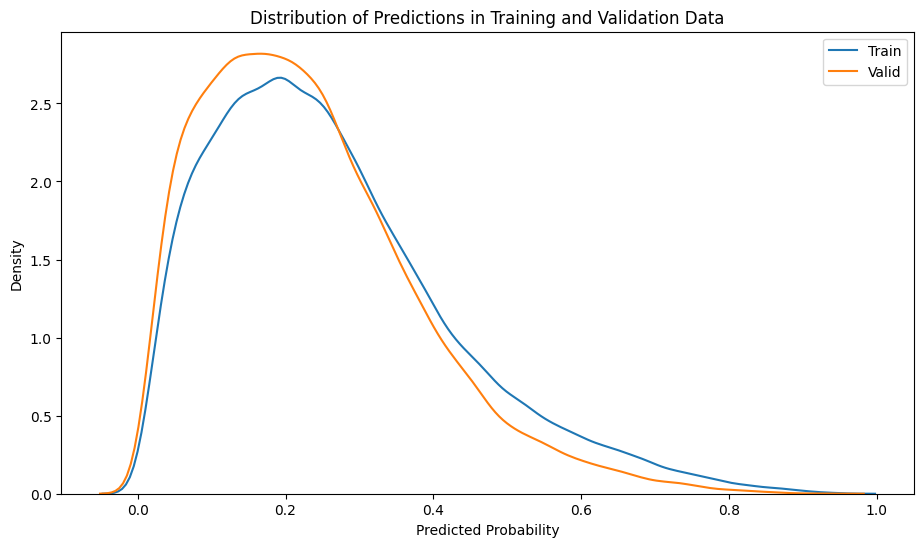

In [53]:
# download
str_filename = 'plt_dist_yhat.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_model}/02_model/{str_variant}/02_model/09_batch_model_eval_valid/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)

# show
Image(filename=str_local_path)

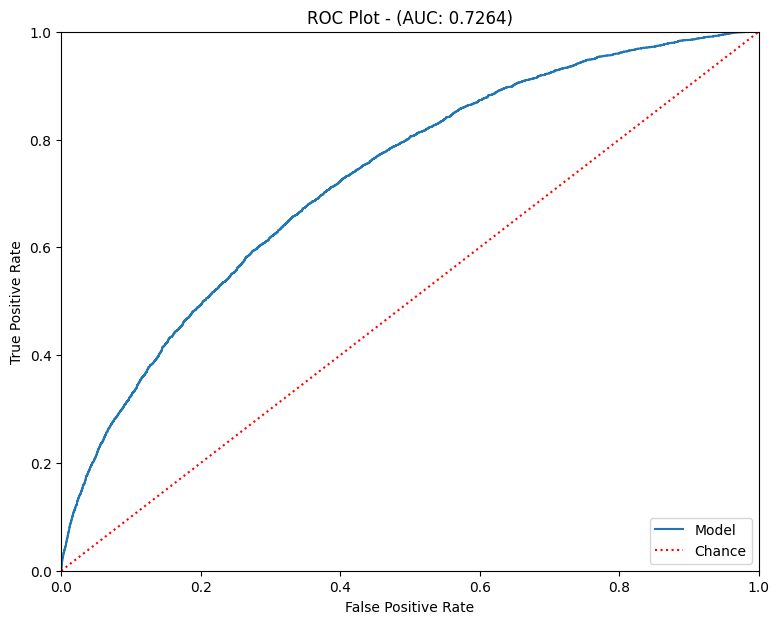

In [54]:
# download
str_filename = 'plt_roc_auc_valid.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_model}/02_model/{str_variant}/02_model/09_batch_model_eval_valid/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)

# show
Image(filename=str_local_path)

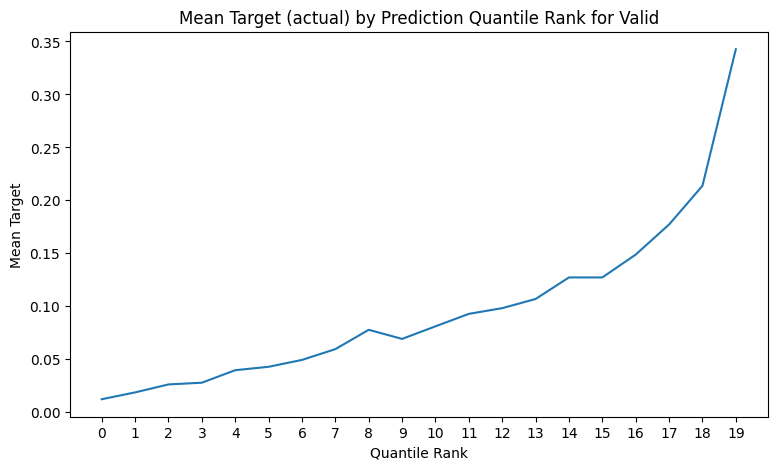

In [55]:
# download
str_filename = 'plt_lift_valid.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_model}/02_model/{str_variant}/02_model/09_batch_model_eval_valid/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)

# show
Image(filename=str_local_path)

### PD plots - Test

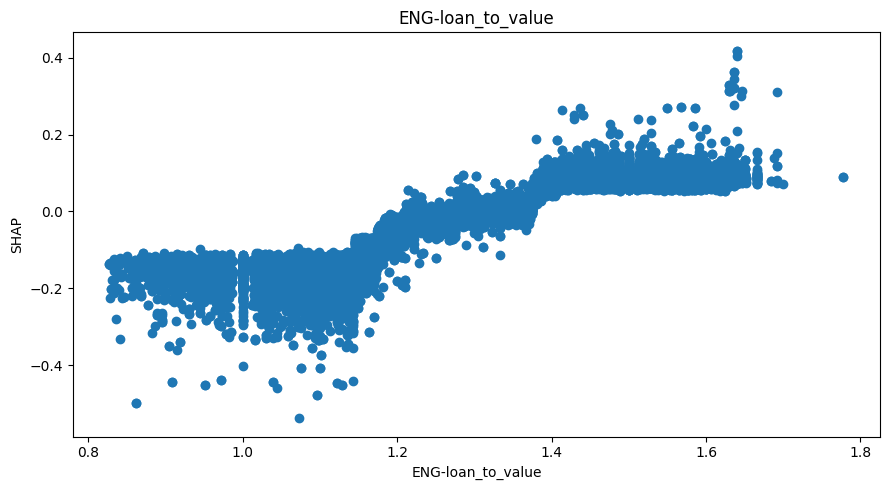

In [56]:
# get the most recently uploaded file
str_prefix = f'{str_model}/02_model/{str_variant}/02_model/10_batch_pd_plots_test/plots'
cls_s3 = boto3.resource('s3')
# initialize bucket
cls_bucket = cls_s3.Bucket(str_project)
# use the bucket objects method to get a list of all objects in the bucket with the specified prefix
objects = cls_bucket.objects.filter(Prefix=str_prefix)
# sort the objects by last modified time
list_sorted_objects = sorted(objects, key=lambda x: x.last_modified, reverse=False)
# get the keys
list_sorted_objects = [obj.key for obj in list_sorted_objects]
# make sure gzip
list_sorted_objects = [str_key for str_key in list_sorted_objects if '.png' in str_key]
# get the key (i.e. filename) of the most recently modified object
str_filename = list_sorted_objects[0].split('/')[-1]

# download
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_prefix}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)

# show
Image(filename=str_local_path)

### Model eval - Test

In [57]:
# download
str_filename = 'dict_eval_metrics_train.json'
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_model}/02_model/{str_variant}/02_model/11_batch_model_eval_test/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
# open
with open(str_local_path, 'r') as f:
    # Load the contents of the file as a Python object
    dict_metrics_train = json.load(f)

# make df
ser_metrics_train = pd.Series(dict_metrics_train)
df_metrics_train = pd.DataFrame({'train': ser_metrics_train})

# download
str_filename = 'dict_eval_metrics_test.json'
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_model}/02_model/{str_variant}/02_model/11_batch_model_eval_test/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
# open
with open(str_local_path, 'r') as f:
    # Load the contents of the file as a Python object
    dict_metrics_test = json.load(f)

# make df
ser_metrics_test = pd.Series(dict_metrics_test)
df_metrics_test = pd.DataFrame({'test': ser_metrics_test})

# join
df_metrics = df_metrics_train.join(df_metrics_test)

# save
str_filename = 'df_test_model_eval_metrics.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_metrics.to_csv(str_local_path, index=False)

# show
df_metrics

,train,test
accuracy,0.305895,0.282584
precision,0.142550,0.121508
recall,0.991144,0.939215
f1,0.249252,0.215178
roc_auc,0.843368,0.695376
pr_auc,0.466393,0.232305
log_loss,0.355787,0.373435


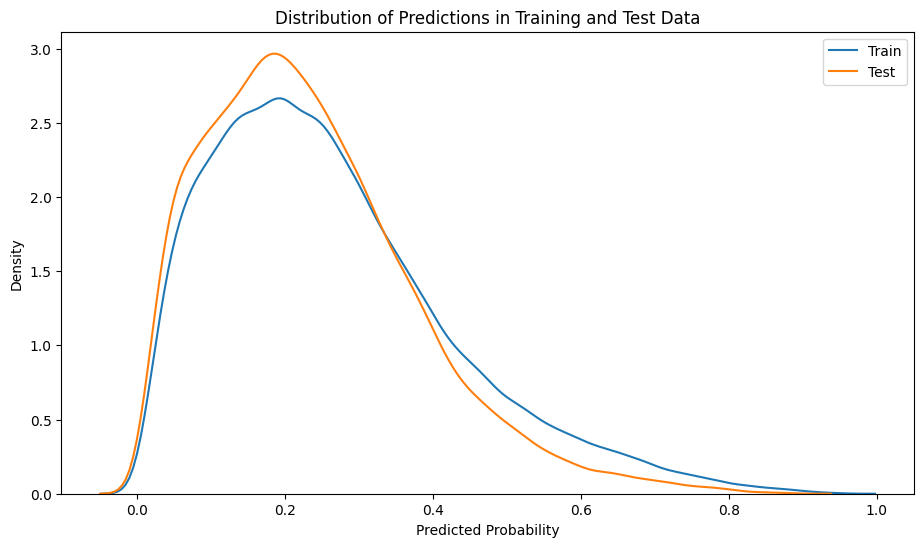

In [58]:
# download
str_filename = 'plt_dist_yhat.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_model}/02_model/{str_variant}/02_model/11_batch_model_eval_test/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)

# show
Image(filename=str_local_path)

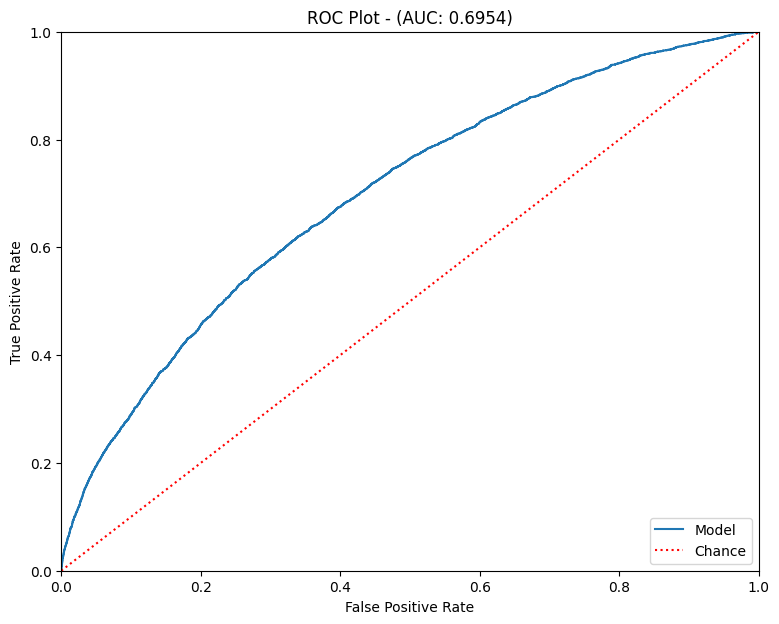

In [59]:
# download
str_filename = 'plt_roc_auc_test.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_model}/02_model/{str_variant}/02_model/11_batch_model_eval_test/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)

# show
Image(filename=str_local_path)

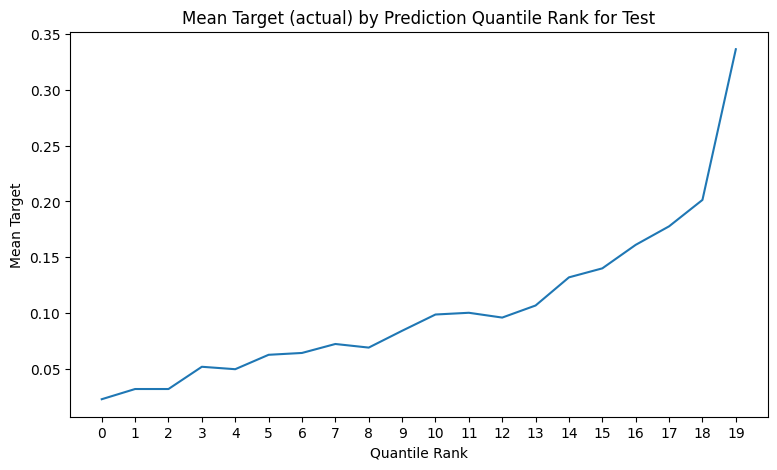

In [60]:
# download
str_filename = 'plt_lift_test.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_model}/02_model/{str_variant}/02_model/11_batch_model_eval_test/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)

# show
Image(filename=str_local_path)